# Análisis Exploratorio de Datos

Autores:
* Belén Huertas Ruiz
* Carlos Naranjo Calderón
* Lucía Sánchez-Chiquito Gómez
* Daniel Sánchez Castro

# Constantes y configuración

In [1]:
import pandas as pd
import os

import matplotlib.pyplot as plt


DATA_DIR = "data"

# `cohorte_pacientes.csv`

In [2]:
df_pacientes_raw = pd.read_csv(os.path.join(DATA_DIR, "cohorte_pacientes_raw.csv"))
df_pacientes = df_pacientes_raw.copy()

In [3]:
df_pacientes_raw

,PacienteID,Genero,Edad,Provincia,Latitud,Longitud
0,1,Masculino,21,Almería,36.8416,-2.4637
1,2,Masculino,84,Huelva,37.2614,-6.9447
2,3,Femenino,59,Córdoba,37.8847,-4.7792
3,4,Femenino,78,Granada,37.1773,-3.5986
4,5,Femenino,31,Málaga,36.7194,-4.4200
5,6,Femenino,47,Córdoba,37.8847,-4.7792
6,7,Masculino,35,Almería,36.8416,-2.4637
7,8,Masculino,19,Granada,37.1773,-3.5986
8,9,Femenino,30,Huelva,37.2614,-6.9447
9,10,Femenino,29,Huelva,37.2614,-6.9447


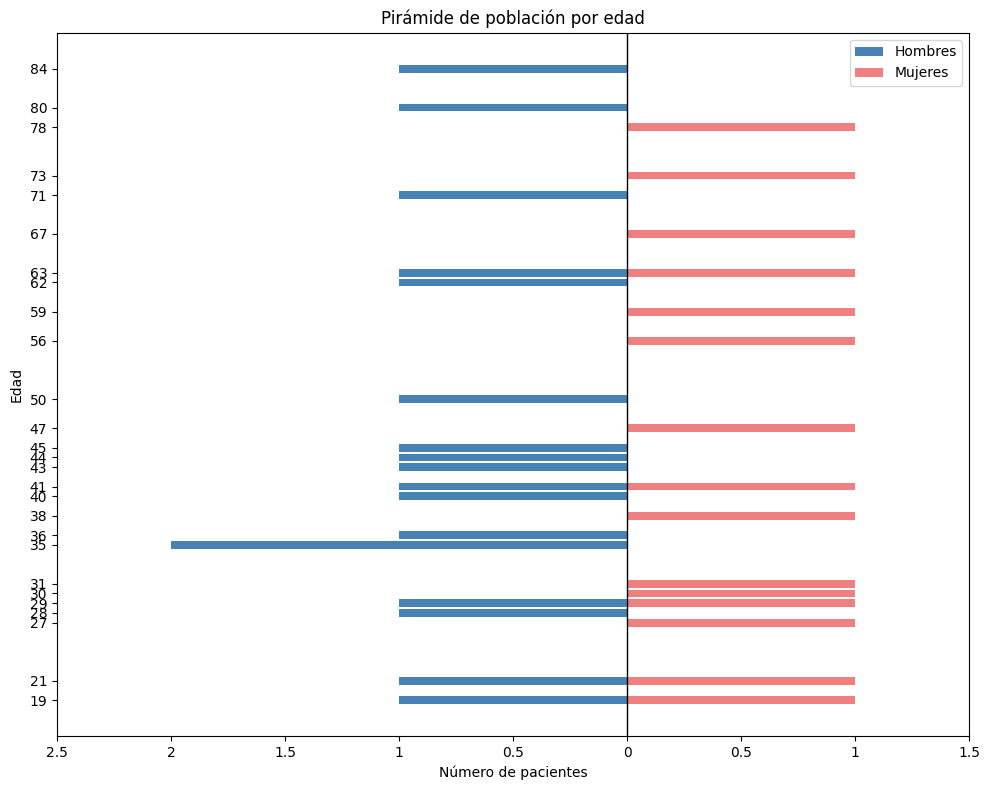

In [4]:
# Pirámide de población por edad y género
piramide = df_pacientes.groupby(["Edad", "Genero"]).size().unstack(fill_value=0)
piramide = piramide.sort_index()

hombres = -piramide.get("Masculino", pd.Series(0, index=piramide.index))
mujeres = piramide.get("Femenino", pd.Series(0, index=piramide.index))

plt.figure(figsize=(10, 8))
plt.barh(piramide.index, hombres, color="steelblue", label="Hombres")
plt.barh(piramide.index, mujeres, color="lightcoral", label="Mujeres")

plt.axvline(0, color="black", linewidth=1)
plt.title("Pirámide de población por edad")
plt.xlabel("Número de pacientes")
plt.ylabel("Edad")
plt.legend()

# Mostrar valores absolutos en el eje X
xticks = plt.xticks()[0]
plt.xticks(xticks, [str(int(abs(x))) if abs(x).is_integer() else f"{abs(x):.1f}" for x in xticks])

# Agregar más ticks en el eje Y
yticks = piramide.index
plt.yticks(yticks, [str(y) for y in yticks])

plt.tight_layout()
plt.show()

In [5]:
df_pacientes["Provincia"].value_counts()

Provincia
Málaga     8
Córdoba    7
Almería    6
Huelva     5
Granada    5
Sevilla    2
Name: count, dtype: int64

## Nuevos datos

In [6]:
df_pacientes.drop(columns=["Latitud", "Longitud"], inplace=True)

In [7]:
import unicodedata
from faker import Faker
import random

fake = Faker('es_ES')

provincias_espana = [
    "Álava", "Albacete", "Alicante", "Almería", "Asturias", "Ávila", "Badajoz", "Baleares",
    "Barcelona", "Burgos", "Cáceres", "Cádiz", "Cantabria", "Castellón", "Ciudad Real",
    "Córdoba", "A Coruña", "Cuenca", "Girona", "Granada", "Guadalajara", "Gipuzkoa",
    "Huelva", "Huesca", "Jaén", "León", "Lleida", "Lugo", "Madrid", "Málaga", "Murcia",
    "Navarra", "Ourense", "Palencia", "Las Palmas", "Pontevedra", "La Rioja", "Salamanca",
    "Segovia", "Sevilla", "Soria", "Tarragona", "Santa Cruz de Tenerife", "Teruel",
    "Toledo", "Valencia", "Valladolid", "Bizkaia", "Zamora", "Zaragoza", "Ceuta", "Melilla"
]

def normalizar_texto(texto):
    """Elimina acentos y convierte a minúsculas."""
    texto = unicodedata.normalize('NFD', texto)
    texto = texto.encode('ascii', 'ignore').decode("utf-8")
    return texto.lower().replace(' ', '_')

def generar_persona(genero=None):
    # 1. Determinamos el género primero
    if genero is None:
        genero = random.choice(["Masculino", "Femenino"])

    # 2. Generamos nombre acorde al género
    if genero == "Masculino":
        nombre_raw = fake.first_name_male()
    elif genero == "Femenino":
        nombre_raw = fake.first_name_female()
    else:
        nombre_raw = fake.first_name()

    apellido_raw = fake.last_name()

    # 3. Limpieza de nombres
    nombre = normalizar_texto(nombre_raw)
    apellido = normalizar_texto(apellido_raw)

    # 4. Resto de datos
    datos = {
        "nombre": nombre,
        "apellido": apellido,
        "genero": genero,
        "telefono": f"+34 {fake.numerify(text='6########')}",
        "provincia": random.choice(provincias_espana),
        "edad": fake.random_int(min=10, max=90)
    }

    return datos

# Ejemplo de uso
persona = generar_persona()
print(persona)

{'nombre': 'florentina', 'apellido': 'alcazar', 'genero': 'Femenino', 'telefono': '+34 622194415', 'provincia': 'Ávila', 'edad': 41}


In [8]:
nombres = []
apellidos = []
telefonos = []

for fila in df_pacientes.itertuples(index=False):
    p = generar_persona(fila.Genero)
    nombres.append(p["nombre"])
    apellidos.append(p["apellido"])
    telefonos.append(p["telefono"])

df_pacientes["nombre"] = nombres
df_pacientes["apellido"] = apellidos
df_pacientes["telefono"] = telefonos

In [9]:
for i in range(len(df_pacientes), 100):
    p = generar_persona()

    df_pacientes.loc[i, "PacienteID"] = i + 1
    df_pacientes.loc[i, "nombre"] = p["nombre"]
    df_pacientes.loc[i, "apellido"] = p["apellido"]
    df_pacientes.loc[i, "Genero"] = p["genero"]
    df_pacientes.loc[i, "telefono"] = p["telefono"]
    df_pacientes.loc[i, "Provincia"] = p["provincia"]
    df_pacientes.loc[i, "Edad"] = p["edad"]

In [10]:
df_pacientes

,PacienteID,Genero,Edad,Provincia,nombre,apellido,telefono
0,1.0,Masculino,21.0,Almería,pepe,navarrete,+34 660268726
1,2.0,Masculino,84.0,Huelva,ildefonso,leal,+34 699127361
2,3.0,Femenino,59.0,Córdoba,vanesa,casanovas,+34 630962867
3,4.0,Femenino,78.0,Granada,ileana,pi,+34 639535091
4,5.0,Femenino,31.0,Málaga,teresita,garriga,+34 615653508
...,...,...,...,...,...,...,...
95,96.0,Masculino,16.0,La Rioja,amor,miralles,+34 661723064
96,97.0,Masculino,54.0,Segovia,leon,cuesta,+34 642543020
97,98.0,Masculino,81.0,Zamora,antonio,prats,+34 687495932
98,99.0,Masculino,68.0,Huesca,josep,marin,+34 673483696


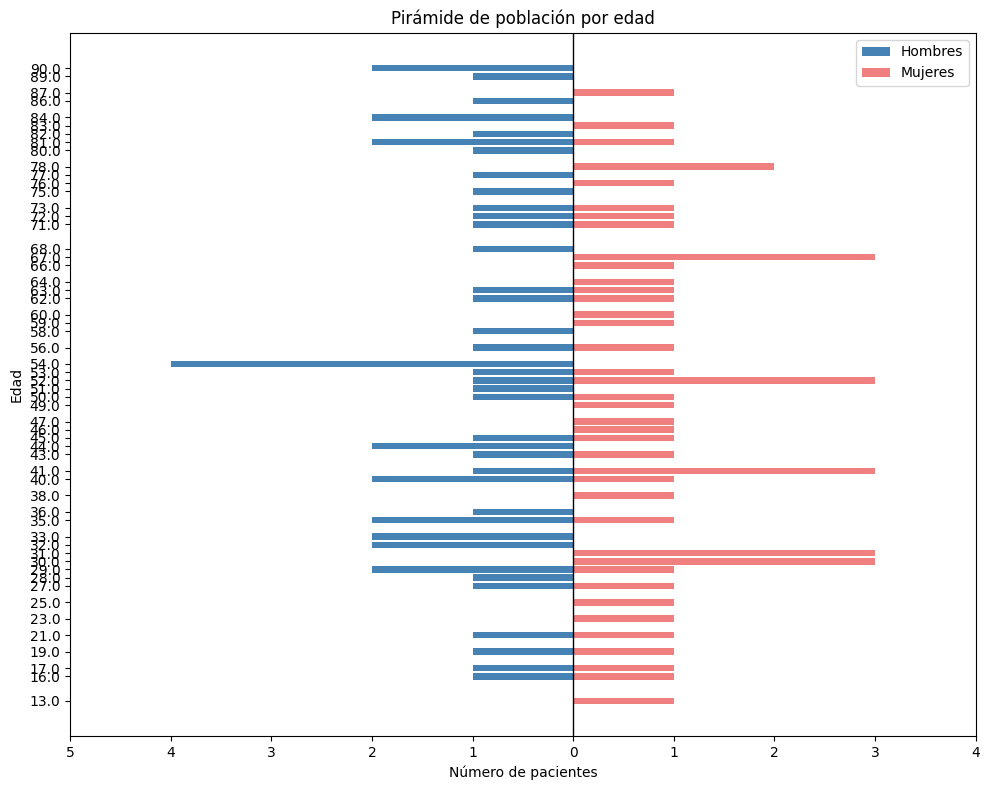

In [11]:
# Pirámide de población por edad y género
piramide = df_pacientes.groupby(["Edad", "Genero"]).size().unstack(fill_value=0)
piramide = piramide.sort_index()

hombres = -piramide.get("Masculino", pd.Series(0, index=piramide.index))
mujeres = piramide.get("Femenino", pd.Series(0, index=piramide.index))

plt.figure(figsize=(10, 8))
plt.barh(piramide.index, hombres, color="steelblue", label="Hombres")
plt.barh(piramide.index, mujeres, color="lightcoral", label="Mujeres")

plt.axvline(0, color="black", linewidth=1)
plt.title("Pirámide de población por edad")
plt.xlabel("Número de pacientes")
plt.ylabel("Edad")
plt.legend()

# Mostrar valores absolutos en el eje X
xticks = plt.xticks()[0]
plt.xticks(xticks, [str(int(abs(x))) if abs(x).is_integer() else f"{abs(x):.1f}" for x in xticks])

# Agregar más ticks en el eje Y
yticks = piramide.index
plt.yticks(yticks, [str(y) for y in yticks])

plt.tight_layout()
plt.show()

In [12]:
df_pacientes.to_csv(os.path.join(DATA_DIR, "cohorte_pacientes.csv"), index=False)

# `cohorte_alergias.csv`

In [13]:
df_alergias_raw = pd.read_csv(os.path.join(DATA_DIR, "cohorte_alergias_raw.csv"))
df_alergias = df_alergias_raw.copy()

In [14]:
df_alergias_raw

,PacienteID,Fecha_diagnostico,Codigo_SNOMED,Descripcion
0,22,2016-08-18,91936005,Alergia al polen
1,11,2023-02-15,91933007,Alergia a los frutos secos
2,27,2019-04-06,300913006,Alergia a la penicilina
3,15,2023-04-24,91931005,Alergia a la leche
4,25,2017-11-14,91931005,Alergia a la leche
...,...,...,...,...
95,12,2016-09-03,300913006,Alergia a la penicilina
96,2,2018-04-12,300914000,Alergia a la aspirina
97,20,2020-11-03,91935009,Alergia al pelo de gato
98,30,2021-05-27,91935009,Alergia al pelo de gato


In [15]:
conteo_alergias = df_alergias[['Codigo_SNOMED', 'Descripcion']].value_counts().reset_index(name='count')
conteo_alergias

,Codigo_SNOMED,Descripcion,count
0,91930004,Alergia a los ácaros del polvo,13
1,300914000,Alergia a la aspirina,12
2,91931005,Alergia a la leche,11
3,91936005,Alergia al polen,11
4,300913006,Alergia a la penicilina,11
5,91934008,Alergia a la picadura de abeja,10
6,91932006,Alergia a los mariscos,9
7,91933007,Alergia a los frutos secos,8
8,414285001,Alergia al látex,8
9,91935009,Alergia al pelo de gato,7


## Nuevos datos

In [16]:
# Catálogo de alergias permitido
catalogo_alergias = conteo_alergias[["Codigo_SNOMED", "Descripcion"]].drop_duplicates().to_dict("records")

paciente_ids = []
fechas_diagnostico = []
codigos_snomed = []
descripciones = []

fecha_min = pd.Timestamp("2016-01-01")
fecha_max = pd.Timestamp("2025-03-10")
rango_dias = (fecha_max - fecha_min).days

for paciente_id in range(34, 101):
    if random.random() < 0.7:  # 70% con al menos una alergia
        n_alergias = random.choices([1, 2], weights=[0.85, 0.15])[0]
        alergias_paciente = random.sample(catalogo_alergias, k=n_alergias)

        for alergia in alergias_paciente:
            fecha_diag = fecha_min + pd.Timedelta(days=random.randint(0, rango_dias))

            paciente_ids.append(paciente_id)
            fechas_diagnostico.append(fecha_diag.strftime("%Y-%m-%d"))
            codigos_snomed.append(alergia["Codigo_SNOMED"])
            descripciones.append(alergia["Descripcion"])

# DataFrame de nuevas filas
nuevas_alergias = pd.DataFrame({
    "PacienteID": paciente_ids,
    "Fecha_diagnostico": fechas_diagnostico,
    "Codigo_SNOMED": codigos_snomed,
    "Descripcion": descripciones,
})

# Añadir
if not nuevas_alergias.empty:
    df_alergias = pd.concat([df_alergias, nuevas_alergias], ignore_index=True)

# Guardar
df_alergias.to_csv(os.path.join(DATA_DIR, "cohorte_alergias.csv"), index=False)

In [17]:
df_alergias

,PacienteID,Fecha_diagnostico,Codigo_SNOMED,Descripcion
0,22,2016-08-18,91936005,Alergia al polen
1,11,2023-02-15,91933007,Alergia a los frutos secos
2,27,2019-04-06,300913006,Alergia a la penicilina
3,15,2023-04-24,91931005,Alergia a la leche
4,25,2017-11-14,91931005,Alergia a la leche
...,...,...,...,...
148,96,2020-03-08,300913006,Alergia a la penicilina
149,97,2016-08-10,300914000,Alergia a la aspirina
150,99,2023-04-13,91930004,Alergia a los ácaros del polvo
151,100,2018-05-16,91932006,Alergia a los mariscos


In [18]:
conteo_alergias = df_alergias[['Codigo_SNOMED', 'Descripcion']].value_counts().reset_index(name='count')
conteo_alergias

,Codigo_SNOMED,Descripcion,count
0,91930004,Alergia a los ácaros del polvo,20
1,300913006,Alergia a la penicilina,20
2,300914000,Alergia a la aspirina,19
3,91931005,Alergia a la leche,16
4,91932006,Alergia a los mariscos,16
5,91933007,Alergia a los frutos secos,16
6,91936005,Alergia al polen,15
7,91934008,Alergia a la picadura de abeja,12
8,414285001,Alergia al látex,10
9,91935009,Alergia al pelo de gato,9


# `cohorte_condiciones.csv`

In [19]:
df_condiciones_raw = pd.read_csv(os.path.join(DATA_DIR, "cohorte_condiciones_raw.csv"))
df_condiciones = df_condiciones_raw.copy()

In [20]:
df_condiciones_raw

,PacienteID,Fecha_inicio,Fecha_fin,Codigo_SNOMED,Descripcion
0,11,2023-11-21 10:18:27.267949,2025-03-10 10:18:27.267949,C0038356,Asma
1,10,2023-12-03 10:18:27.267949,2025-03-10 10:18:27.267949,C0020538,Diabetes tipo 2
2,20,2023-03-16 00:00:00.000000,2023-04-16 00:00:00.000000,C0027651,Migraña
3,17,2023-06-20 00:00:00.000000,2023-06-27 00:00:00.000000,C0027651,Migraña
4,8,2023-03-26 00:00:00.000000,2024-03-01 00:00:00.000000,C0009450,Neumonía
...,...,...,...,...,...
95,28,2023-09-24 00:00:00.000000,2024-09-02 00:00:00.000000,C0027651,Migraña
96,29,2023-10-13 10:18:27.267949,2025-03-10 10:18:27.267949,C0038356,Asma
97,13,2024-11-01 00:00:00.000000,2024-12-11 00:00:00.000000,C0042109,Fractura de brazo
98,27,2024-12-28 00:00:00.000000,2025-01-31 00:00:00.000000,C0042109,Fractura de brazo


In [21]:
conteo_condiciones = df_condiciones[['Codigo_SNOMED', 'Descripcion']].value_counts().reset_index(name='count')
conteo_condiciones

,Codigo_SNOMED,Descripcion,count
0,C0027651,Migraña,16
1,C0011849,Hipertensión,15
2,C0020538,Diabetes tipo 2,14
3,C0009450,Neumonía,14
4,C0038356,Asma,13
5,C0032285,Bronquitis,11
6,C0042109,Fractura de brazo,10
7,C0024117,Gripe,7


In [22]:
df_condiciones["duracion"] = pd.to_datetime(df_condiciones["Fecha_fin"]) - pd.to_datetime(df_condiciones["Fecha_inicio"])

In [23]:
df_condiciones["duracion"].describe()

count                            100
mean               286 days 22:04:48
std      247 days 12:59:22.211287024
min                  3 days 00:00:00
25%                 24 days 12:00:00
50%                342 days 12:00:00
75%                491 days 06:00:00
max                718 days 00:00:00
Name: duracion, dtype: object

In [24]:
stats_duracion_condicion = df_condiciones.groupby(['Codigo_SNOMED', 'Descripcion'])['duracion'].describe()
stats_duracion_condicion

,,count,mean,std,min,25%,50%,75%,max
Codigo_SNOMED,Descripcion,,,,,,,,
C0009450,Neumonía,14,121 days 05:08:34.285714286,150 days 09:02:57.428839730,4 days 00:00:00,9 days 18:00:00,31 days 00:00:00,280 days 00:00:00,360 days 00:00:00
C0011849,Hipertensión,15,555 days 14:24:00,108 days 01:12:10.423739802,412 days 00:00:00,464 days 00:00:00,546 days 00:00:00,653 days 00:00:00,712 days 00:00:00
C0020538,Diabetes tipo 2,14,559 days 08:34:17.142857144,106 days 16:58:11.783566638,410 days 00:00:00,466 days 00:00:00,542 days 12:00:00,659 days 12:00:00,718 days 00:00:00
C0024117,Gripe,7,11 days 00:00:00,11 days 08:56:22.393491762,3 days 00:00:00,3 days 12:00:00,6 days 00:00:00,16 days 00:00:00,29 days 00:00:00
C0027651,Migraña,16,122 days 04:30:00,145 days 23:42:23.380404736,3 days 00:00:00,6 days 12:00:00,29 days 00:00:00,205 days 18:00:00,359 days 00:00:00
C0032285,Bronquitis,11,143 days 13:05:27.272727272,158 days 16:31:35.300610460,20 days 00:00:00,26 days 00:00:00,36 days 00:00:00,323 days 12:00:00,362 days 00:00:00
C0038356,Asma,13,496 days 18:27:41.538461536,68 days 08:42:59.549047890,384 days 00:00:00,460 days 00:00:00,489 days 00:00:00,557 days 00:00:00,603 days 00:00:00
C0042109,Fractura de brazo,10,76 days 02:24:00,113 days 13:26:25.589291876,4 days 00:00:00,8 days 00:00:00,29 days 12:00:00,68 days 12:00:00,349 days 00:00:00


## Nuevos datos

In [25]:
df_condiciones.to_csv(os.path.join(DATA_DIR, "cohorte_condiciones.csv"), index=False)

In [26]:
import pandas as pd
import numpy as np

# Catalogo de condiciones permitido
catalogo = df_condiciones[['Codigo_SNOMED', 'Descripcion']].value_counts().reset_index(name='count')
paciente_ids = []
fechas_inicio = []
fechas_fin = []
codigos_snomed = []
descripciones = []

fecha_min = pd.Timestamp("2016-01-01")
fecha_max = pd.Timestamp("2025-03-10")
rango_dias = (fecha_max - fecha_min).days

# Reproducible
rng = np.random.default_rng(42)

nuevos = []
for paciente_id in range(34, 101):  # 34 a 100 inclusive
    codigo, descripcion = catalogo.iloc[rng.integers(0, len(catalogo))][['Codigo_SNOMED', 'Descripcion']]

    # Fecha inicio aleatoria
    fecha_inicio = pd.Timestamp("2023-01-01") + pd.to_timedelta(int(rng.integers(0, 700)), unit="D")
    # Duracion aleatoria entre 3 y 720 dias
    dias = int(rng.integers(3, 721))
    fecha_fin = fecha_inicio + pd.Timedelta(days=dias)

    nuevos.append({
        "PacienteID": paciente_id,
        "Fecha_inicio": fecha_inicio,
        "Fecha_fin": fecha_fin,
        "Codigo_SNOMED": codigo,
        "Descripcion": descripcion,
    })

df_nuevos = pd.DataFrame(nuevos)

# Calcular duracion con tu formula
df_nuevos["duracion"] = pd.to_datetime(df_nuevos["Fecha_fin"]) - pd.to_datetime(df_nuevos["Fecha_inicio"])


if not df_nuevos.empty:
    df_condiciones = pd.concat([df_condiciones, df_nuevos], ignore_index=True)

df_condiciones.to_csv(os.path.join(DATA_DIR, "cohorte_condiciones.csv"), index=False)

In [27]:
df_condiciones

,PacienteID,Fecha_inicio,Fecha_fin,Codigo_SNOMED,Descripcion,duracion
0,11,2023-11-21 10:18:27.267949,2025-03-10 10:18:27.267949,C0038356,Asma,475 days
1,10,2023-12-03 10:18:27.267949,2025-03-10 10:18:27.267949,C0020538,Diabetes tipo 2,463 days
2,20,2023-03-16 00:00:00.000000,2023-04-16 00:00:00.000000,C0027651,Migraña,31 days
3,17,2023-06-20 00:00:00.000000,2023-06-27 00:00:00.000000,C0027651,Migraña,7 days
4,8,2023-03-26 00:00:00.000000,2024-03-01 00:00:00.000000,C0009450,Neumonía,341 days
...,...,...,...,...,...,...
162,96,2023-09-24 00:00:00,2024-03-16 00:00:00,C0011849,Hipertensión,174 days
163,97,2024-04-23 00:00:00,2025-07-22 00:00:00,C0020538,Diabetes tipo 2,455 days
164,98,2023-09-11 00:00:00,2025-08-03 00:00:00,C0038356,Asma,692 days
165,99,2023-08-28 00:00:00,2023-11-23 00:00:00,C0027651,Migraña,87 days


In [28]:
df_condiciones["duracion"].describe()

count                            167
mean     312 days 23:08:15.808383232
std      234 days 14:04:56.531993944
min                  3 days 00:00:00
25%                 46 days 00:00:00
50%                347 days 00:00:00
75%                499 days 00:00:00
max                718 days 00:00:00
Name: duracion, dtype: object

In [29]:
stats_duracion_condicion = df_condiciones.groupby(['Codigo_SNOMED', 'Descripcion'])['duracion'].describe()
stats_duracion_condicion

,,count,mean,std,min,25%,50%,75%,max
Codigo_SNOMED,Descripcion,,,,,,,,
C0009450,Neumonía,27,236 days 07:06:40,207 days 16:48:48.715166646,4 days 00:00:00,31 days 00:00:00,201 days 00:00:00,377 days 12:00:00,619 days 00:00:00
C0011849,Hipertensión,25,443 days 21:07:12,188 days 03:36:23.917069836,44 days 00:00:00,362 days 00:00:00,460 days 00:00:00,558 days 00:00:00,712 days 00:00:00
C0020538,Diabetes tipo 2,22,504 days 22:54:32.727272728,187 days 13:52:33.750628364,25 days 00:00:00,449 days 00:00:00,526 days 00:00:00,659 days 12:00:00,718 days 00:00:00
C0024117,Gripe,13,128 days 05:32:18.461538462,196 days 08:20:28.008312888,3 days 00:00:00,6 days 00:00:00,27 days 00:00:00,236 days 00:00:00,644 days 00:00:00
C0027651,Migraña,23,211 days 20:52:10.434782608,217 days 20:53:52.864651668,3 days 00:00:00,7 days 00:00:00,148 days 00:00:00,358 days 00:00:00,703 days 00:00:00
C0032285,Bronquitis,19,239 days 17:41:03.157894736,209 days 23:44:19.223730420,20 days 00:00:00,33 days 00:00:00,313 days 00:00:00,381 days 00:00:00,548 days 00:00:00
C0038356,Asma,17,465 days 00:00:00,182 days 00:25:13.114013724,29 days 00:00:00,444 days 00:00:00,489 days 00:00:00,564 days 00:00:00,692 days 00:00:00
C0042109,Fractura de brazo,21,222 days 19:25:42.857142856,206 days 09:23:26.894396762,4 days 00:00:00,34 days 00:00:00,201 days 00:00:00,349 days 00:00:00,661 days 00:00:00


# `cohorte_encuentros.csv`

In [30]:
df_encuentros_raw = pd.read_csv(os.path.join(DATA_DIR, "cohorte_encuentros_raw.csv"))
df_encuentros = df_encuentros_raw.copy()

In [31]:
df_encuentros_raw

,PacienteID,Tipo_encuentro,Fecha_inicio,Fecha_fin
0,1,Hospitalización,2024-11-11,2024-12-05
1,1,Hospitalización,2023-06-23,2023-07-10
2,1,Urgencia,2024-02-10,2024-02-16
3,2,Hospitalización,2024-01-17,2024-02-06
4,2,Atención Primaria,2023-06-13,2023-06-23
...,...,...,...,...
107,29,Atención Primaria,2025-03-03,2025-03-09
108,30,Urgencia,2024-05-07,2024-05-09
109,30,Atención Primaria,2024-01-07,2024-01-17
110,30,Hospitalización,2025-02-02,2025-03-04


In [32]:
df_encuentros["Tipo_encuentro"].value_counts()

Tipo_encuentro
Urgencia             42
Hospitalización      36
Atención Primaria    34
Name: count, dtype: int64

In [33]:
ids_pacientes = df_encuentros_raw["PacienteID"].dropna().astype(int).sort_values().unique()
print(ids_pacientes)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30]


In [34]:
df_encuentros["duracion"] = pd.to_datetime(df_encuentros["Fecha_fin"]) - pd.to_datetime(df_encuentros["Fecha_inicio"])

In [35]:
df_encuentros["duracion"].describe()

count                          112
mean     9 days 04:04:17.142857142
std      8 days 01:52:46.828210233
min                1 days 00:00:00
25%                3 days 00:00:00
50%                7 days 00:00:00
75%               10 days 00:00:00
max               30 days 00:00:00
Name: duracion, dtype: object

In [36]:
stats_duracion_encuentros = df_encuentros.groupby(['Tipo_encuentro'])['duracion'].describe()
stats_duracion_encuentros

,count,mean,std,min,25%,50%,75%,max
Tipo_encuentro,,,,,,,,
Atención Primaria,34,5 days 09:52:56.470588235,3 days 05:30:51.570186461,1 days 00:00:00,2 days 00:00:00,5 days 12:00:00,8 days 00:00:00,10 days 00:00:00
Hospitalización,36,17 days 08:40:00,9 days 03:49:31.386897454,4 days 00:00:00,8 days 18:00:00,17 days 00:00:00,27 days 00:00:00,30 days 00:00:00
Urgencia,42,5 days 04:34:17.142857142,3 days 03:11:42.278313871,1 days 00:00:00,2 days 00:00:00,5 days 12:00:00,8 days 00:00:00,10 days 00:00:00


## Nuevos datos

In [37]:
df_encuentros.to_csv(os.path.join(DATA_DIR, "cohorte_encuentros.csv"), index=False)

In [38]:
# Tipos de encuentro y pesos observados
tipos_validos = df_encuentros["Tipo_encuentro"].value_counts()
tipos = tipos_validos.index.tolist()
pesos = tipos_validos.values.tolist()

# Rango temporal para generar fechas
fecha_min = pd.Timestamp("2016-01-01")
fecha_max = pd.Timestamp("2025-03-10")

nuevos_encuentros = []

for paciente_id in range(34, 101):
    # Un paciente puede tener varios encuentros
    n_encuentros = random.choices([0,1, 2, 3, 4], weights=[0.30, 0.45, 0.30, 0.18, 0.07])[0]

    for _ in range(n_encuentros):
        # Mantener distribución de tipos similar al histórico
        tipo = random.choices(tipos, weights=pesos, k=1)[0]

        # Fecha de inicio aleatoria en el rango definido
        fecha_inicio = fake.date_between(start_date=fecha_min.date(), end_date=fecha_max.date())
        fecha_inicio = pd.Timestamp(fecha_inicio)

        # Duración según tipo (sin crear tipos nuevos)
        if tipo == "Hospitalización":
            dias = random.randint(4, 30)
        else:  # "Atención Primaria" o "Urgencia"
            dias = random.randint(1, 10)

        fecha_fin = fecha_inicio + pd.Timedelta(days=dias)

        nuevos_encuentros.append({
            "PacienteID": paciente_id,
            "Tipo_encuentro": tipo,
            "Fecha_inicio": fecha_inicio.strftime("%Y-%m-%d"),
            "Fecha_fin": fecha_fin.strftime("%Y-%m-%d"),
            "duracion": pd.Timedelta(days=dias),
        })

df_nuevos_encuentros = pd.DataFrame(nuevos_encuentros)

# Añadir al dataframe principal
df_encuentros = pd.concat([df_encuentros, df_nuevos_encuentros], ignore_index=True)

# Opcional: ordenar para facilitar lectura
df_encuentros = df_encuentros.sort_values(["PacienteID", "Fecha_inicio"]).reset_index(drop=True)

# Guardar
df_encuentros.to_csv(os.path.join(DATA_DIR, "cohorte_encuentros.csv"), index=False)

In [39]:
df_encuentros

,PacienteID,Tipo_encuentro,Fecha_inicio,Fecha_fin,duracion
0,1,Hospitalización,2023-06-23,2023-07-10,17 days
1,1,Urgencia,2024-02-10,2024-02-16,6 days
2,1,Hospitalización,2024-11-11,2024-12-05,24 days
3,2,Atención Primaria,2023-06-13,2023-06-23,10 days
4,2,Atención Primaria,2024-01-09,2024-01-17,8 days
...,...,...,...,...,...
196,99,Hospitalización,2017-08-12,2017-09-11,30 days
197,99,Urgencia,2019-09-18,2019-09-24,6 days
198,99,Hospitalización,2023-10-07,2023-10-12,5 days
199,99,Hospitalización,2024-03-20,2024-03-28,8 days


In [40]:
ids_pacientes = df_encuentros["PacienteID"].dropna().astype(int).sort_values().unique()
print(ids_pacientes)

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  34  35  38  39  41  42
  44  45  47  48  49  50  54  55  56  57  58  59  60  61  62  63  64  65
  66  67  70  73  74  75  77  78  79  80  82  83  84  85  87  89  90  92
  93  94  95  96  97  99 100]


# `cohorte_medicationes.csv`

In [41]:
df_medicationes_raw = pd.read_csv(os.path.join(DATA_DIR, "cohorte_medicationes_raw.csv"))
df_medicationes = df_medicationes_raw.copy()

In [42]:
df_medicationes_raw

,PacienteID,Fecha de inicio,Fecha de fin,Código,Nombre,Dosis,Frecuencia,Vía de administración
0,1,2018-06-01,NaN,C09AA03,Lisinopril,10 mg,1 vez al día,oral
1,1,2019-01-15,NaN,C03AA03,Hidroclorotiazida,25 mg,1 vez al día,oral
2,1,2018-06-05,NaN,C10AA05,Atorvastatina,20 mg,1 vez al día,oral
3,1,2018-06-01,NaN,B01AC06,Ácido acetilsalicílico,100 mg,1 vez al día,oral
4,2,2017-04-01,NaN,A10BA02,Metformina,500 mg,2 veces al día,oral
...,...,...,...,...,...,...,...,...
95,38,2017-01-01,2018-01-01,H02AB07,Prednisona,20 mg,1 vez al día,oral
96,39,2020-07-01,NaN,G03BA03,Testosterona enantato,250 mg,1 vez cada 3 semanas,inyección
97,40,2019-05-01,NaN,S01ED01,Timolol (colirio),0.5%,2 veces al día,oftálmica
98,41,2021-04-10,2021-05-10,S01GX09,Olopatadina (colirio),0.1%,2 veces al día,oftálmica


In [43]:
conteo_medicationes = df_medicationes[['Código', 'Nombre']].value_counts().reset_index(name='count')
conteo_medicationes

,Código,Nombre,count
0,H02AB07,Prednisona,4
1,B01AC06,Ácido acetilsalicílico,2
2,A02BC01,Omeprazol,2
3,N02BE01,Paracetamol,2
4,R01AD08,Fluticasona (spray nasal),2
...,...,...,...
86,R03DX07,Roflumilast,1
87,R06AE07,Cetirizina,1
88,R06AX13,Loratadina,1
89,S01ED01,Timolol (colirio),1


## Nuevos datos

In [44]:
df_medicationes.to_csv(os.path.join(DATA_DIR, "cohorte_medicationes.csv"), index=False)

In [45]:

import re

# Catálogo válido (mantiene combinaciones reales de la tabla)
catalogo_med = (
    df_medicationes[["Código", "Nombre", "Frecuencia", "Vía de administración"]]
    .value_counts()
    .reset_index(name="count")
)

# Rango temporal
fecha_min = pd.Timestamp("2016-01-01")
fecha_max = pd.Timestamp("2025-03-10")

# ---- Preparación de dosis: min/max por Código a partir de los datos existentes ----
def extraer_valor_unidad(dosis):
    if pd.isna(dosis):
        return None, None
    s = str(dosis).strip().replace(",", ".")
    m = re.search(r"(\d+(?:\.\d+)?)\s*([a-zA-Zµμ/]+)", s)
    if not m:
        return None, None
    return float(m.group(1)), m.group(2)

dosis_base = df_medicationes[["Código", "Dosis"]].copy()
dosis_base[["valor", "unidad"]] = dosis_base["Dosis"].apply(lambda x: pd.Series(extraer_valor_unidad(x)))
dosis_base = dosis_base.dropna(subset=["valor", "unidad"])

stats_dosis = (
    dosis_base.groupby(["Código", "unidad"])["valor"].agg(["min", "max", "count"]).reset_index())

# Para cada código, usar la unidad más frecuente y su rango min/max
idx = stats_dosis.groupby("Código")["count"].idxmax()
rango_dosis_codigo = stats_dosis.loc[idx, ["Código", "unidad", "min", "max"]].set_index("Código")

# Fallback: dosis reales por código
dosis_reales_por_codigo = (
    df_medicationes.groupby("Código")["Dosis"]
    .apply(lambda s: [x for x in s.dropna().astype(str).tolist() if x.strip() != ""]).to_dict()
)

nuevas_med = []

for paciente_id in range(34, 101):
    # Número de tratamientos por paciente
    n_meds = random.choices([0, 1, 2, 3, 4], weights=[0.20, 0.45, 0.25, 0.08, 0.02])[0]

    for _ in range(n_meds):
        # Selección de código/nombre/frecuencia/vía solo de valores existentes
        fila = catalogo_med.sample(
            n=1,
            weights=catalogo_med["count"],
            replace=True,
            random_state=None
        ).iloc[0]

        codigo = fila["Código"]
        nombre = fila["Nombre"]
        frecuencia = fila["Frecuencia"]
        via = fila["Vía de administración"]

        # Fecha inicio aleatoria
        fecha_inicio = fake.date_between(start_date=fecha_min.date(), end_date=fecha_max.date())
        fecha_inicio = pd.Timestamp(fecha_inicio)

        # 30% medicación activa (sin fecha fin)
        if random.random() < 0.30:
            fecha_fin = pd.NaT
        else:
            dias = random.randint(7, 365)
            fecha_fin = fecha_inicio + pd.Timedelta(days=dias)
            if fecha_fin > fecha_max:
                fecha_fin = fecha_max

        # Dosis dentro del rango observado para ese código (min/max)
        if codigo in rango_dosis_codigo.index:
            unidad = rango_dosis_codigo.loc[codigo, "unidad"]
            dmin = float(rango_dosis_codigo.loc[codigo, "min"])
            dmax = float(rango_dosis_codigo.loc[codigo, "max"])

            # Entera si ambos extremos son enteros, si no 1 decimal
            if dmin.is_integer() and dmax.is_integer():
                valor = random.randint(int(dmin), int(dmax))
                dosis = f"{valor} {unidad}"
            else:
                valor = round(random.uniform(dmin, dmax), 1)
                dosis = f"{valor} {unidad}"
        else:
            # Fallback: tomar una dosis existente para ese código
            opciones = dosis_reales_por_codigo.get(codigo, ["10 mg"])
            dosis = random.choice(opciones)

        nuevas_med.append({
            "PacienteID": paciente_id,
            "Fecha de inicio": fecha_inicio.strftime("%Y-%m-%d"),
            "Fecha de fin": "" if pd.isna(fecha_fin) else fecha_fin.strftime("%Y-%m-%d"),
            "Código": codigo,
            "Nombre": nombre,
            "Dosis": dosis,
            "Frecuencia": frecuencia,
            "Vía de administración": via
        })

df_nuevas_med = pd.DataFrame(nuevas_med)

# Añadir al dataframe principal
if not df_nuevas_med.empty:
    df_medicationes = pd.concat([df_medicationes, df_nuevas_med], ignore_index=True)

# Guardar con la misma estructura de columnas
df_medicationes.to_csv(os.path.join(DATA_DIR, "cohorte_medicationes.csv"), index=False)

# `cohorte_procedimientos.csv`

In [46]:
df_procedimientos_raw = pd.read_csv(os.path.join(DATA_DIR, "cohorte_procedimientos_raw.csv"))
df_procedimientos = df_procedimientos_raw.copy()

In [47]:
df_procedimientos_raw

,PacienteID,Fecha_inicio,Fecha_fin,Codigo_SNOMED,Descripcion
0,6,2024-10-11,2024-10-13,303893007,Resonancia magnética cerebral
1,13,2023-06-09,2023-06-12,241879003,Extracción de muela
2,8,2023-09-08,2023-09-10,80146002,Cirugía de apendicitis
3,4,2023-04-10,2023-04-14,303893007,Resonancia magnética cerebral
4,9,2024-03-26,2024-03-31,80146002,Cirugía de apendicitis
...,...,...,...,...,...
95,10,2024-10-12,2024-10-19,241879003,Extracción de muela
96,2,2024-05-09,2024-05-12,387713003,Electrocardiograma
97,24,2024-05-04,2024-05-06,48387007,Colonoscopía
98,30,2023-10-17,2023-10-19,180325003,Vacunación contra la gripe


In [48]:
conteo_procedimientos = df_procedimientos[['Codigo_SNOMED', 'Descripcion']].value_counts().reset_index(name='count')
conteo_procedimientos

,Codigo_SNOMED,Descripcion,count
0,303893007,Resonancia magnética cerebral,13
1,80146002,Cirugía de apendicitis,11
2,399439001,Cateterismo cardíaco,11
3,233604007,Ecografía abdominal,11
4,241879003,Extracción de muela,11
5,430193006,Sutura de herida,11
6,399208008,Radiografía de tórax,10
7,180325003,Vacunación contra la gripe,9
8,48387007,Colonoscopía,7
9,387713003,Electrocardiograma,6


In [49]:
df_procedimientos["duracion"] = pd.to_datetime(df_procedimientos["Fecha_fin"]) - pd.to_datetime(df_procedimientos["Fecha_inicio"])

In [50]:
df_procedimientos["duracion"].describe()

count                          100
mean               4 days 07:26:24
std      1 days 22:06:27.152186273
min                1 days 00:00:00
25%                3 days 00:00:00
50%                4 days 00:00:00
75%                6 days 00:00:00
max                7 days 00:00:00
Name: duracion, dtype: object

In [51]:
stats_duracion_procedimientos = df_procedimientos.groupby(['Codigo_SNOMED', 'Descripcion'])['duracion'].describe()
stats_duracion_procedimientos

,,count,mean,std,min,25%,50%,75%,max
Codigo_SNOMED,Descripcion,,,,,,,,
48387007,Colonoscopía,7,3 days 10:17:08.571428571,2 days 08:53:27.142732585,1 days 00:00:00,1 days 12:00:00,3 days 00:00:00,5 days 00:00:00,7 days 00:00:00
80146002,Cirugía de apendicitis,11,4 days 08:43:38.181818181,2 days 00:19:34.192443487,1 days 00:00:00,2 days 12:00:00,5 days 00:00:00,6 days 00:00:00,7 days 00:00:00
180325003,Vacunación contra la gripe,9,4 days 13:20:00,2 days 00:09:58.961934609,1 days 00:00:00,4 days 00:00:00,5 days 00:00:00,6 days 00:00:00,7 days 00:00:00
233604007,Ecografía abdominal,11,4 days 10:54:32.727272727,1 days 16:40:40.411710081,1 days 00:00:00,4 days 00:00:00,4 days 00:00:00,5 days 00:00:00,7 days 00:00:00
241879003,Extracción de muela,11,5 days 02:10:54.545454545,1 days 07:12:30.205728662,3 days 00:00:00,4 days 00:00:00,5 days 00:00:00,6 days 00:00:00,7 days 00:00:00
303893007,Resonancia magnética cerebral,13,4 days 11:04:36.923076923,1 days 12:09:12.667752439,2 days 00:00:00,4 days 00:00:00,4 days 00:00:00,5 days 00:00:00,7 days 00:00:00
387713003,Electrocardiograma,6,5 days 00:00:00,2 days 00:00:00,2 days 00:00:00,3 days 18:00:00,6 days 00:00:00,6 days 00:00:00,7 days 00:00:00
399208008,Radiografía de tórax,10,3 days 12:00:00,1 days 22:59:21.697792378,1 days 00:00:00,2 days 06:00:00,3 days 12:00:00,4 days 00:00:00,7 days 00:00:00
399439001,Cateterismo cardíaco,11,4 days 10:54:32.727272727,2 days 08:08:42.958077053,1 days 00:00:00,2 days 00:00:00,5 days 00:00:00,6 days 12:00:00,7 days 00:00:00


## Nuevos datos

In [52]:
df_procedimientos.to_csv(os.path.join(DATA_DIR, "cohorte_procedimientos.csv"), index=False)

In [53]:
# Catálogo válido: solo combinaciones existentes en la tabla
catalogo_proc = (
    df_procedimientos[["Codigo_SNOMED", "Descripcion"]].value_counts().reset_index(name="count")
)

# Duración histórica por procedimiento (en días) para respetar rangos observados
base_dias = (
    pd.to_datetime(df_procedimientos["Fecha_fin"], errors="coerce")- pd.to_datetime(df_procedimientos["Fecha_inicio"], errors="coerce")).dt.days

tmp = df_procedimientos[["Codigo_SNOMED", "Descripcion"]].copy()
tmp["dias"] = base_dias
tmp = tmp.dropna(subset=["dias"])
tmp["dias"] = tmp["dias"].astype(int)

rango_dias_proc = (
    tmp.groupby(["Codigo_SNOMED", "Descripcion"])["dias"].agg(["min", "max"]).reset_index())

rango_dict = {
    (r.Codigo_SNOMED, r.Descripcion): (int(r["min"]), int(r["max"]))for _, r in rango_dias_proc.iterrows()}

# Rango temporal
fecha_min = pd.Timestamp("2016-01-01")
fecha_max = pd.Timestamp("2025-03-10")

nuevos_proc = []

for paciente_id in range(34, 101):
    # Nº de procedimientos por paciente
    n_proc = random.choices([0, 1, 2, 3], weights=[0.30, 0.45, 0.20, 0.05])[0]

    for _ in range(n_proc):
        # Elegir solo SNOMED + descripción existentes
        fila = catalogo_proc.sample(n=1, weights=catalogo_proc["count"], replace=True).iloc[0]
        codigo = fila["Codigo_SNOMED"]
        desc = fila["Descripcion"]

        # Fecha de inicio aleatoria
        fecha_inicio = pd.Timestamp(
            fake.date_between(start_date=fecha_min.date(), end_date=fecha_max.date())
        )

        # Duración según rango histórico del mismo procedimiento
        dmin, dmax = rango_dict.get((codigo, desc), (1, 7))
        dias = random.randint(dmin, dmax)

        fecha_fin = fecha_inicio + pd.Timedelta(days=dias)
        if fecha_fin > fecha_max:
            fecha_fin = fecha_max
            dias = (fecha_fin - fecha_inicio).days
            if dias < 1:
                dias = 1
                fecha_inicio = fecha_fin - pd.Timedelta(days=1)

        nuevos_proc.append({
            "PacienteID": paciente_id,
            "Fecha_inicio": fecha_inicio.strftime("%Y-%m-%d"),
            "Fecha_fin": fecha_fin.strftime("%Y-%m-%d"),
            "Codigo_SNOMED": codigo,
            "Descripcion": desc,
            "duracion": f"{dias} days"
        })

df_nuevos_proc = pd.DataFrame(nuevos_proc)

if not df_nuevos_proc.empty:
    df_procedimientos = pd.concat([df_procedimientos, df_nuevos_proc], ignore_index=True)

# Guardar
df_procedimientos.to_csv(os.path.join(DATA_DIR, "cohorte_procedimientos.csv"), index=False)